In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt


Accuracy Word2Vec: 0.6715
Accuracy SBERT   : 0.7181



,Word2Vec,SBERT
negative,0.49,0.63
neutral,0.78,0.80
positive,0.46,0.56


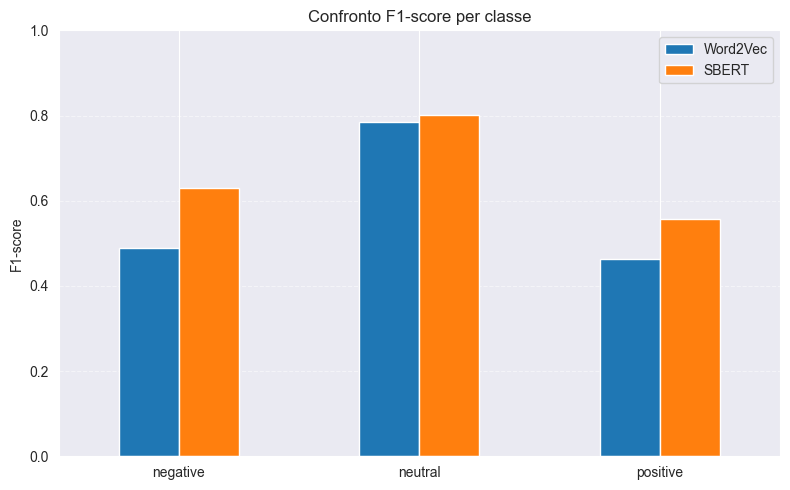

In [10]:

# Percorsi ai file delle metriche
word2vec_path = "../data/models/metrics_word2vec.json"
sbert_path = "../data/models/metrics_sbert.json"

# Carica i file
with open(word2vec_path) as f:
    word2vec_metrics = json.load(f)

with open(sbert_path) as f:
    sbert_metrics = json.load(f)

# Stampa accuracy
print("Accuracy Word2Vec:", round(word2vec_metrics["accuracy"], 4))
print("Accuracy SBERT   :", round(sbert_metrics["accuracy"], 4))
print()

# Confronto classification_report per classe
labels = ["negative", "neutral", "positive"]

# Costruzione dataframe
df = pd.DataFrame({
    "Word2Vec": [word2vec_metrics["report"][label]["f1-score"] for label in labels],
    "SBERT": [sbert_metrics["report"][label]["f1-score"] for label in labels]
}, index=labels)

# Visualizza tabella
display(df.style.format("{:.2f}").set_caption("F1-score per classe"))

# Grafico a barre
df.plot(kind="bar", figsize=(8, 5))
plt.title("Confronto F1-score per classe")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
